In [1]:
library(tidyterra)
library(terra)
library(geodata)
library(rnaturalearth)
library(ggplot2)
library(dplyr)
library(sf)
library(rlang)
library(knitr)
library(leaflet)
library(htmlwidgets)
library(htmltools)
library(raster)
library(IRdisplay)


Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.9.27




Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




...

The following object is masked from ‘package:terra’:

    spin




Loading required package: sp




Attaching package: ‘raster’




The following object is masked from ‘package:dplyr’:

    select




The following object is masked from ‘package:tidyterra’:

    select




## Reloading the elevation surface

This notebook **rebuilds** the UK elevation raster the same way as in `01_terrain_analysis.Rmd`, so it can be rendered on its own. In a larger project you might save an intermediate **GeoTIFF** under `data/` and read it with **`terra::rast()`** to avoid duplicate downloads.

In [2]:
uk_elev <- geodata::elevation_30s(country = "GBR", path = tempdir())
uk_boundary <- rnaturalearth::ne_countries(
  country = "United Kingdom",
  scale = "medium",
  returnclass = "sv"
)

if (!terra::same.crs(uk_elev, uk_boundary)) {
  uk_boundary <- terra::project(uk_boundary, uk_elev)
}

uk_elev_masked <- terra::mask(terra::crop(uk_elev, uk_boundary), uk_boundary)
elev_layer <- names(uk_elev_masked)[1]
uk_elev_masked <- uk_elev_masked |>
  tidyterra::rename(elevation = !!rlang::sym(elev_layer))

Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmp0I80S5/elevation/GBR_elv_msk.zip



## Club locations and CRS

Premiership grounds are stored as a **data frame** of **longitude** and **latitude** in **decimal degrees**. **`EPSG:4326`** is the standard **WGS84** geographic CRS used by GPS and most global rasters (including the elevation and WorldClim grids used here): positions are angles on the ellipsoid, not metres on a flat map.

In [3]:
rclubs <- data.frame(
  club = c(
    "Bath Rugby", "Bristol Bears", "Exeter Chiefs", "Gloucester Rugby",
    "Harlequins", "Leicester Tigers", "Newcastle Falcons",
    "Northampton Saints", "Sale Sharks", "Saracens"
  ),
  lon = c(
    -2.361, -2.571, -3.525, -2.243, -0.215, -1.133,
    -1.622, -0.906, -2.338, -0.100
  ),
  lat = c(
    51.381, 51.455, 50.730, 51.866, 51.481, 52.620,
    54.961, 52.241, 53.419, 51.674
  ),
  region = c(
    "South West", "South West", "South West", "South West",
    "London", "Midlands", "North",
    "Midlands", "North", "London"
  )
)

clubs_sv <- terra::vect(rclubs, geom = c("lon", "lat"), crs = "EPSG:4326")

## Raster–point extraction

**`terra::extract()`** performs a **spatial intersection** between a raster and a set of **sample locations** (points, polygons, or another raster). For points, each location receives the **cell value(s)** of the raster layer(s) at the containing cell (by default the cell **centre** rule applies for points). That is how we attach **terrain height** at each stadium to the club table.

In [4]:
elev_at_clubs <- terra::extract(uk_elev_masked, clubs_sv)

clubs_elev <- rclubs |>
  mutate(ground_elevation_m = elev_at_clubs[["elevation"]])

clubs_elev |>
  arrange(desc(ground_elevation_m)) |>
  kable(digits = 1, caption = "Premiership grounds ranked by extracted elevation (m)")



Table: Premiership grounds ranked by extracted elevation (m)

|club               |  lon|  lat|region     | ground_elevation_m|
|:------------------|----:|----:|:----------|------------------:|
|Leicester Tigers   | -1.1| 52.6|Midlands   |                 82|
|Northampton Saints | -0.9| 52.2|Midlands   |                 63|
|Saracens           | -0.1| 51.7|London     |                 58|
|Exeter Chiefs      | -3.5| 50.7|South West |                 54|
|Bath Rugby         | -2.4| 51.4|South West |                 31|
|Newcastle Falcons  | -1.6| 55.0|North      |                 29|
|Sale Sharks        | -2.3| 53.4|North      |                 28|
|Gloucester Rugby   | -2.2| 51.9|South West |                 18|
|Bristol Bears      | -2.6| 51.5|South West |                 14|
|Harlequins         | -0.2| 51.5|London     |                  8|

Geographically, **south-western** clubs such as **Exeter Chiefs** sit on higher ground than **London** sides (**Harlequins**, **Saracens**), which lie in the low-lying **Thames** basin. **Newcastle Falcons** in the north-east can be relatively high or low depending on fine-scale coastal versus inland cells, but the table makes the **ranking** explicit from the grid we used.

The bar chart below uses the same extracted elevations, with clubs ordered from **lowest** to **highest** ground so you can read off the full spread at a glance (still tied to the SRTM-scale raster cells used above).

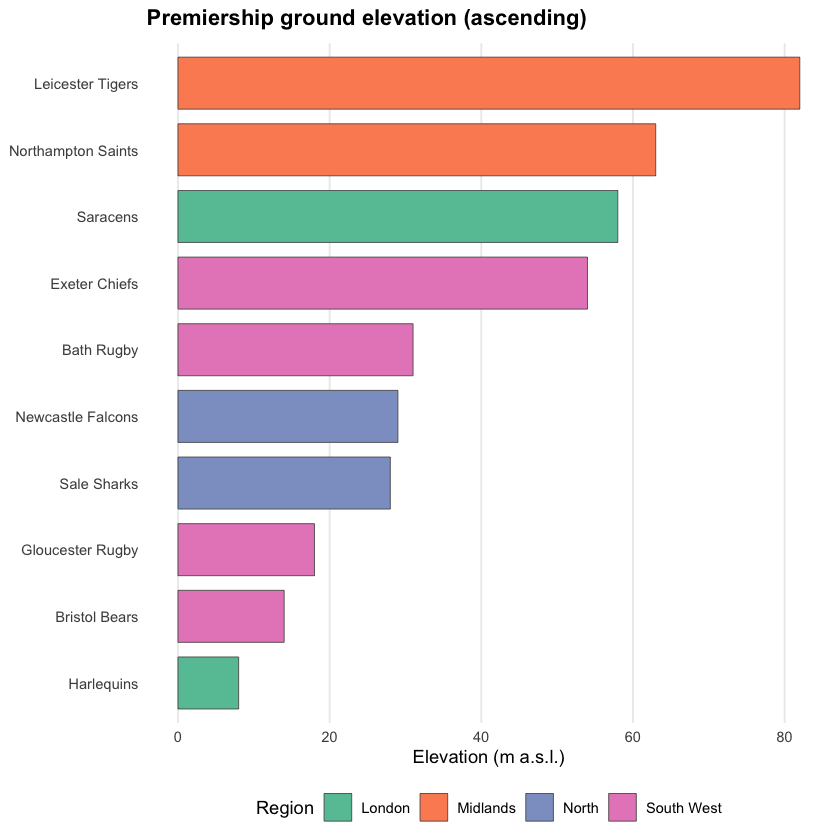

In [5]:
clubs_elev_bar <- clubs_elev |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(clubs_elev_bar, aes(x = club, y = ground_elevation_m, fill = region)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set2", name = "Region") +
  labs(
    title = "Premiership ground elevation (ascending)",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

<SpatRaster> resampled to 500980 cells.


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the tidyterra package.
  Please report the issue at <https://github.com/dieghernan/tidyterra/issues>.”


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


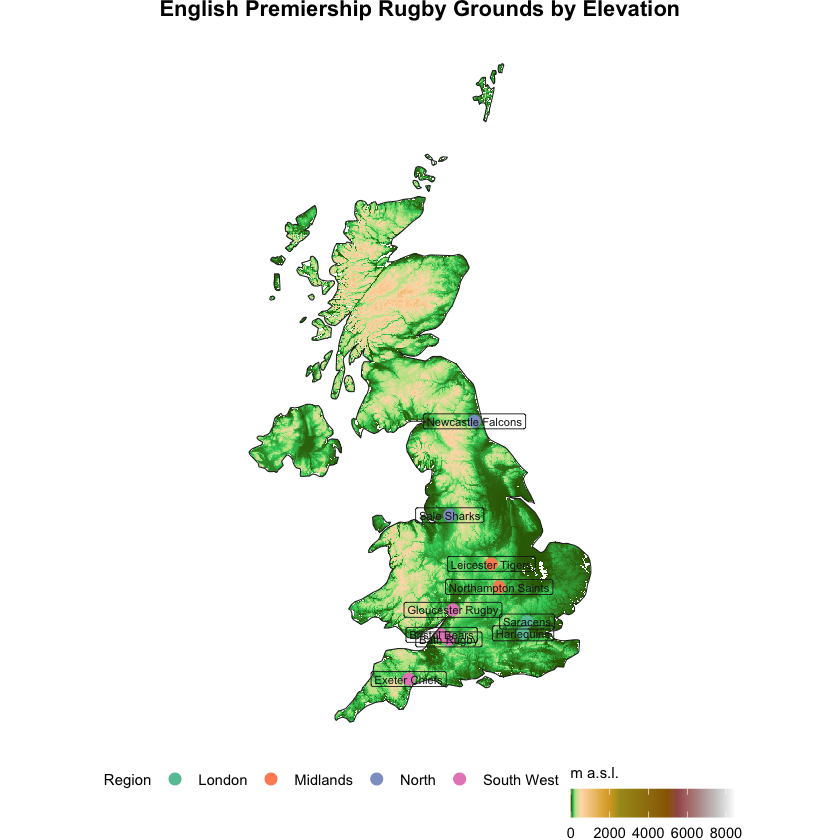

In [6]:
ggplot() +
  tidyterra::geom_spatraster(data = uk_elev_masked, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m a.s.l.",
    guide = guide_colorbar(barwidth = unit(3.5, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = clubs_sv, aes(colour = region), size = 3, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = clubs_sv,
    aes(label = club),
    size = 2.4,
    colour = "grey10",
    label.size = 0.15,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = uk_boundary, fill = NA, colour = "grey15", linewidth = 0.3) +
  scale_colour_brewer(palette = "Set2", name = "Region") +
  labs(title = "English Premiership Rugby Grounds by Elevation") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", margin = margin(b = 6)),
    legend.title = element_text(size = 9),
    legend.position = "bottom"
  )

### Interactive map

The map below uses **Leaflet** (via **`htmlwidgets`**). You can **pan**, **zoom**, and click stadium markers for **club**, **region**, and **extracted elevation**. Marker colours follow the same **elevation colour scale** as the terrain layer. An internet connection is required for the light **basemap** tiles.

In [7]:
prem_ext <- terra::extend(terra::ext(clubs_sv), 1.5)
r_prem <- terra::crop(uk_elev_masked, prem_ext)

flip_raster_east_west <- function(r) {
  mat <- terra::values(r, mat = TRUE)
  mat <- mat[, rev(seq_len(ncol(mat))), drop = FALSE]
  terra::values(r) <- mat
  r
}

leaflet_elev_map <- function(r, clubs_df) {
  r_small <- terra::aggregate(r, fact = 4, fun = mean)
  if (!grepl("4326", terra::crs(r_small, describe = TRUE)$code)) {
    r_small <- terra::project(r_small, "EPSG:4326")
  }
  r_small <- flip_raster_east_west(r_small)
  vals <- terra::values(r_small)
  vals <- vals[!is.na(vals)]
  elev_domain <- range(
    c(vals, clubs_df$ground_elevation_m),
    na.rm = TRUE
  )

  pal <- leaflet::colorNumeric(
    grDevices::terrain.colors(60),
    domain = elev_domain,
    na.color = "#808080"
  )

  lng1 <- terra::xmin(r_small)
  lng2 <- terra::xmax(r_small)
  lat1 <- terra::ymin(r_small)
  lat2 <- terra::ymax(r_small)
  bounds_ok <- all(is.finite(c(lng1, lng2, lat1, lat2))) &&
    lng1 < lng2 &&
    lat1 < lat2
  center_lng <- mean(clubs_df$lon, na.rm = TRUE)
  center_lat <- mean(clubs_df$lat, na.rm = TRUE)
  marker_fill <- unname(pal(clubs_df$ground_elevation_m))

  map <- leaflet::leaflet(
    width = "100%",
    height = 480,
    options = leaflet::leafletOptions(minZoom = 5)
  )

  map <- if (bounds_ok) {
    leaflet::fitBounds(map, lng1, lat1, lng2, lat2)
  } else {
    leaflet::setView(map, center_lng, center_lat, zoom = 6)
  }

  map |>
    leaflet::addProviderTiles(
      "CartoDB.Positron",
      group = "Basemap"
    ) |>
    leaflet::addRasterImage(
      r_small,
      colors = pal,
      opacity = 0.78,
      project = FALSE,
      group = "Elevation (SRTM)"
    ) |>
    leaflet::addLegend(
      pal = pal,
      values = vals,
      title = "Elevation (m)",
      position = "bottomright",
      opacity = 0.9
    ) |>
    leaflet::addCircleMarkers(
      lng = clubs_df$lon,
      lat = clubs_df$lat,
      radius = 8,
      stroke = TRUE,
      weight = 1.5,
      color = "#333333",
      fillColor = marker_fill,
      fillOpacity = 0.92,
      popup = paste0(
        "<strong>", clubs_df$club, "</strong><br>",
        "<em>", clubs_df$region, "</em><br>",
        round(clubs_df$ground_elevation_m, 1), " m a.s.l."
      ),
      group = "Stadiums"
    ) |>
    leaflet::addLayersControl(
      baseGroups = "Basemap",
      overlayGroups = c("Elevation (SRTM)", "Stadiums"),
      options = leaflet::layersControlOptions(collapsed = FALSE)
    )
}

find_book_root <- function() {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  for (steps in 0:6) {
    root <- if (steps == 0) {
      wd
    } else {
      normalizePath(
        file.path(wd, paste(rep("..", steps), collapse = "/")),
        winslash = "/",
        mustWork = FALSE
      )
    }
    if (file.exists(file.path(root, "_config.yml"))) {
      return(root)
    }
  }
  stop("Could not find Jupyter Book root (_config.yml).")
}

include_leaflet_map <- function(map, title, file_stem) {
  maps_dir <- file.path(find_book_root(), "_static", "uk-terrain-rugby", "maps")
  dir.create(maps_dir, recursive = TRUE, showWarnings = FALSE)
  out_path <- file.path(maps_dir, paste0(file_stem, ".html"))
  suppressWarnings(htmlwidgets::saveWidget(map, out_path, selfcontained = TRUE))
  iframe_src <- paste0("../../_static/uk-terrain-rugby/maps/", file_stem, ".html")
  iframe_html <- sprintf(
    paste0(
      "<h4 style=\"text-align:center;font-weight:bold;margin:0.6em 0 0.2em 0;\">%s</h4>",
      "<iframe src=\"%s\" title=\"%s\" width=\"100%%\" height=\"500\" ",
      "style=\"border:none;\"></iframe>"
    ),
    htmltools::htmlEscape(title),
    iframe_src,
    htmltools::htmlEscape(title)
  )
  IRdisplay::display_html(iframe_html)
  invisible(NULL)
}

In [8]:
include_leaflet_map(
  leaflet_elev_map(r_prem, clubs_elev),
  "English Premiership (interactive)",
  "premiership_uk"
)

English Premiership (interactive)

**`geom_spatvector_label()`** draws text from **SpatVector** attributes; where labels crowd together in static output, **ggrepel** could be swapped in with an **sf** conversion for automatic jittering.